# Quantitative-DeFi-Research

**Author:** Sana Ur Rehman  
**Profession:** Data Scientist  
**Created:** 2026  

---

## License

This project is licensed under the **MIT License**. 

You are free to use, modify, distribute, and build upon this work for both commercial and non-commercial purposes, provided you give appropriate **credit** to the original author. For the full legal text and conditions, please refer to the `LICENSE` file included in this project's repository.

---

## Citation

If you reference or build upon this project, please provide appropriate credit.

For formal citation information, please see the project's `README.md` and `CITATION.cff` files.

Fetching 1m data for BTC-USD (Last 7d)...
Fetching 1m data for ETH-USD (Last 7d)...

Aligning timestamps...

--- Data Stats ---
Total Data Points (Minutes): 9192
Correlation (BTC vs ETH): 0.9835
Data saved to 'hft_pair_data.csv'


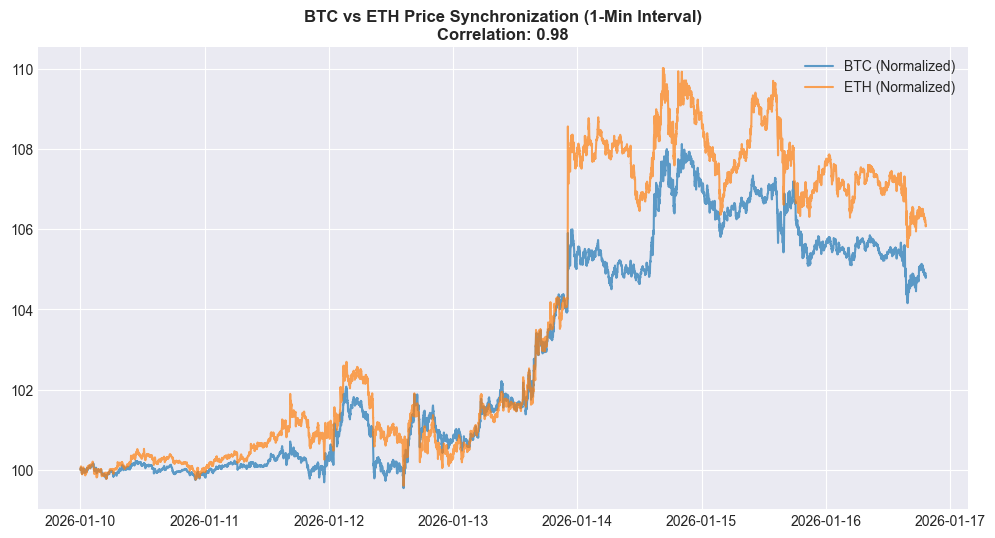

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

def fetch_intraday_data(ticker, period='7d', interval='1m'):
    """
    Fetches high-frequency intraday data (1-minute intervals).
    Note: Yahoo Finance limits 1m data to the last 7 days.
    """
    print(f"Fetching {interval} data for {ticker} (Last {period})...")
    data = yf.download(ticker, period=period, interval=interval, progress=False, auto_adjust=True)
    
    # Flatten MultiIndex if present
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    
    # Clean and rename
    df = data[['Close']].copy()
    df.rename(columns={'Close': ticker}, inplace=True)
    
    # Drop missing values immediately
    df.dropna(inplace=True)
    return df

if __name__ == "__main__":
    # 1. Fetch Data for the Pair
    # BTC and ETH are chosen because they are the most liquid and correlated pair.
    btc = fetch_intraday_data('BTC-USD')
    eth = fetch_intraday_data('ETH-USD')
    
    # 2. Merge Dataframes on Timestamp
    # This ensures we only analyze minutes where BOTH assets traded (synchronicity).
    print("\nAligning timestamps...")
    pair_data = pd.merge(btc, eth, left_index=True, right_index=True, how='inner')
    
    # 3. Quick Correlation Check
    corr = pair_data.corr().iloc[0,1]
    print(f"\n--- Data Stats ---")
    print(f"Total Data Points (Minutes): {len(pair_data)}")
    print(f"Correlation (BTC vs ETH): {corr:.4f}")
    
    # 4. Save
    pair_data.to_csv('hft_pair_data.csv')
    print("Data saved to 'hft_pair_data.csv'")
    
    # 5. Visual Inspection of Correlation
    # Normalize to start at 100 for visual comparison
    normalized_data = pair_data / pair_data.iloc[0] * 100
    
    plt.figure(figsize=(12, 6))
    plt.plot(normalized_data.index, normalized_data['BTC-USD'], label='BTC (Normalized)', alpha=0.7)
    plt.plot(normalized_data.index, normalized_data['ETH-USD'], label='ETH (Normalized)', alpha=0.7)
    plt.title(f'BTC vs ETH Price Synchronization (1-Min Interval)\nCorrelation: {corr:.2f}', fontsize=12, fontweight='bold')
    plt.legend()
    plt.show()